# Zadanie 1 Klasyfikacja obrazów: CIFAR-100

**Cel:** klasyfikacja obrazów 32×32 RGB. Dla wykonalności na CPU bierzemy **podzbiór 20 klas**

**Zbiór:** `tf.keras.datasets.cifar100` (50 000 train + 10 000 test, 100 klas, 32×32×3).


## 1. Importy i konfiguracja

In [24]:
from Wspolne import ustaw_seed, wykres_krzywych_uczenia, macierz_pomylek, raport_klasyfikacji, tabela_porownawcza
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.applications import EfficientNetB0
from sklearn.model_selection import train_test_split

ustaw_seed(42)
LICZBA_KLAS = 20 

## 2. Wczytanie danych i podzbiór klas

In [25]:
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')
maska_train = y_train.ravel() < LICZBA_KLAS
maska_test = y_test.ravel() < LICZBA_KLAS
x_train, y_train = x_train[maska_train], y_train[maska_train].ravel()
x_test, y_test = x_test[maska_test], y_test[maska_test].ravel()
print("Train:", x_train.shape, "| Test:", x_test.shape)
print("Klasy:", np.unique(y_train))

Train: (10000, 32, 32, 3) | Test: (2000, 32, 32, 3)
Klasy: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


## 3. Poznanie danych 

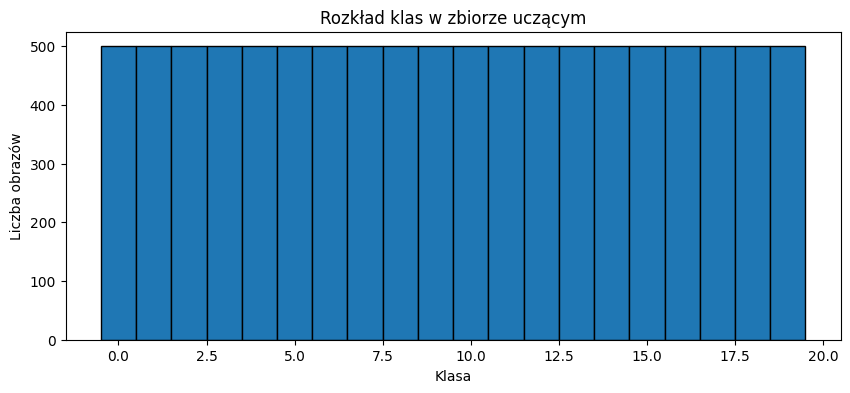

In [26]:
plt.figure(figsize=(10, 4))
plt.hist(y_train, bins=np.arange(LICZBA_KLAS + 1) - 0.5, edgecolor='black')
plt.title('Rozkład klas w zbiorze uczącym')
plt.xlabel('Klasa')
plt.ylabel('Liczba obrazów')
plt.show()

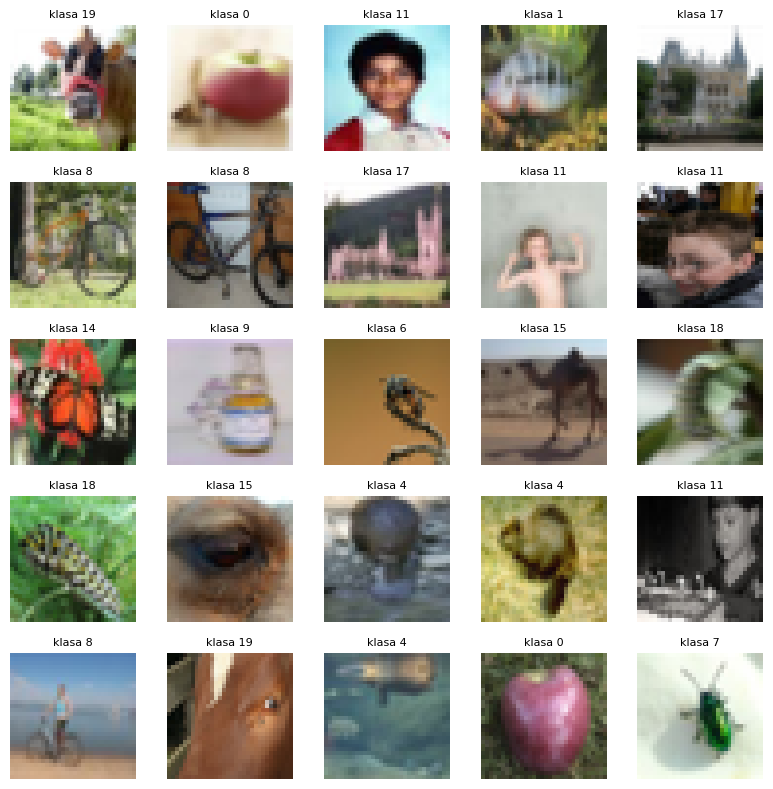

In [27]:
plt.figure(figsize=(8, 8))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(f'klasa {y_train[i]}', fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Przygotowanie danych

In [28]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
print("Train:", x_tr.shape, "Val:", x_val.shape)

augmentacja = Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name='augmentacja')

Train: (8000, 32, 32, 3) Val: (2000, 32, 32, 3)


## 5. Funkcje pomocnicze

In [29]:
def trenuj(model, epochs=30, batch_size=64):
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    return model.fit(x_tr, y_tr, validation_data=(x_val, y_val), epochs=epochs, batch_size=batch_size, callbacks=[stop], verbose=0)


def oblicz_metryki(model):
    pred = model.predict(x_test, verbose=0)
    y_pred = pred.argmax(axis=1)
    accuracy = (y_pred == y_test).mean()
    top5 = np.mean(np.any(pred.argsort(axis=1)[:, -5:] == y_test.reshape(-1, 1), axis=1))
    return {'accuracy': float(accuracy), 'top5': float(top5)}


wyniki = {}  

## 6. Model bazowy: MLP

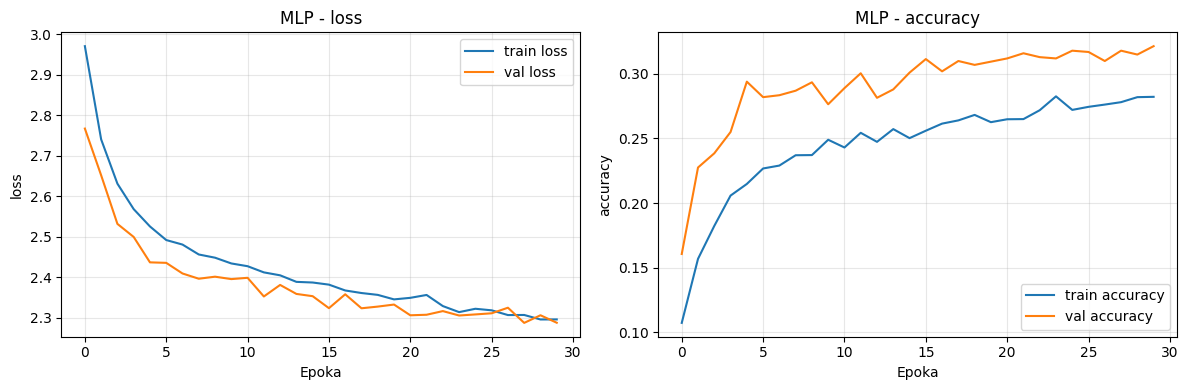

{'accuracy': 0.312, 'top5': 0.7095}


In [30]:
model_mlp = Sequential([
    layers.Input((32, 32, 3)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(LICZBA_KLAS, activation='softmax'),
])
historia = trenuj(model_mlp)
wykres_krzywych_uczenia(historia, metryki=('loss', 'accuracy'), tytul='MLP')
wyniki['MLP'] = oblicz_metryki(model_mlp)
print(wyniki['MLP'])

## 7. Model: prosta CNN

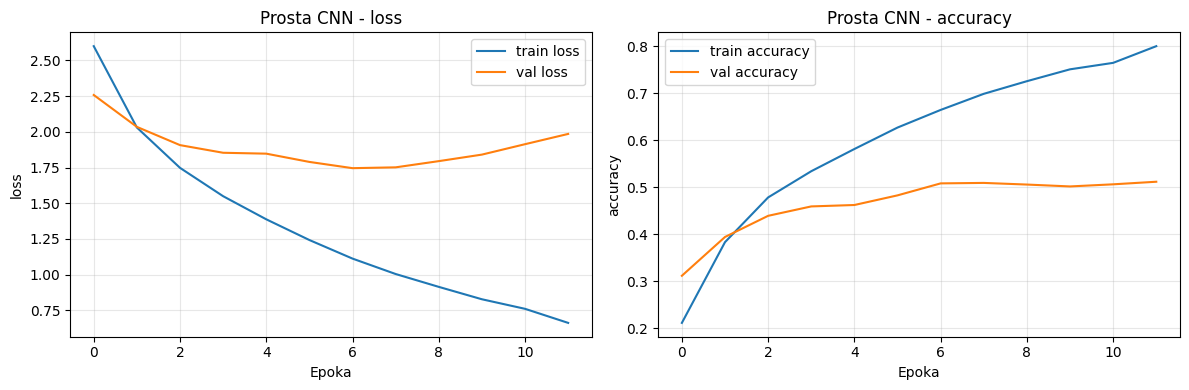

{'accuracy': 0.5145, 'top5': 0.848}


In [31]:
model_cnn = Sequential([
    layers.Input((32, 32, 3)),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPool2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPool2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(LICZBA_KLAS, activation='softmax'),
])
historia = trenuj(model_cnn)
wykres_krzywych_uczenia(historia, metryki=('loss', 'accuracy'), tytul='Prosta CNN')
wyniki['CNN'] = oblicz_metryki(model_cnn)
print(wyniki['CNN'])

## 8. Model: CNN z regularyzacją

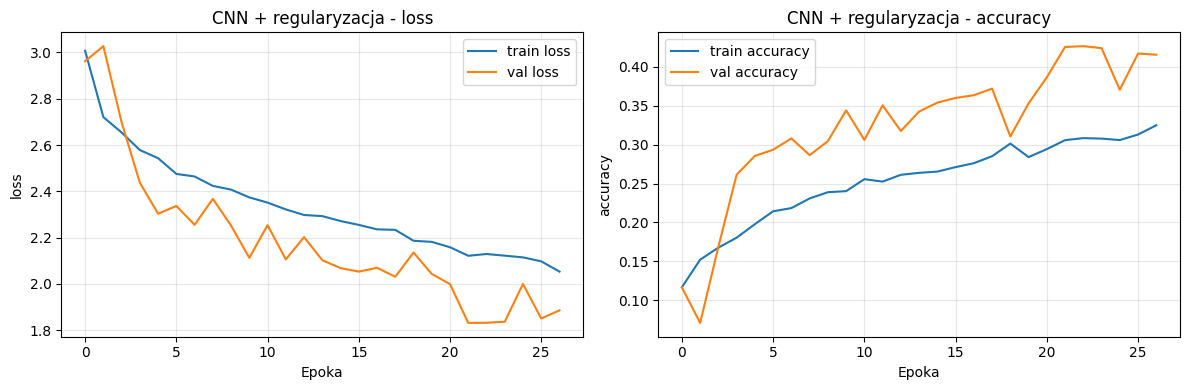

{'accuracy': 0.4505, 'top5': 0.828}


In [32]:
model_cnn_reg = Sequential([
    layers.Input((32, 32, 3)),
    augmentacja,
    layers.Conv2D(32, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
    layers.Conv2D(32, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
    layers.MaxPool2D(),
    layers.Conv2D(64, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
    layers.Conv2D(64, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
    layers.MaxPool2D(),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(LICZBA_KLAS, activation='softmax'),
])
historia = trenuj(model_cnn_reg, epochs=40)
wykres_krzywych_uczenia(historia, metryki=('loss', 'accuracy'), tytul='CNN + regularyzacja')
wyniki['CNN+reg'] = oblicz_metryki(model_cnn_reg)
print(wyniki['CNN+reg'])

## 8. Model: transfer learning

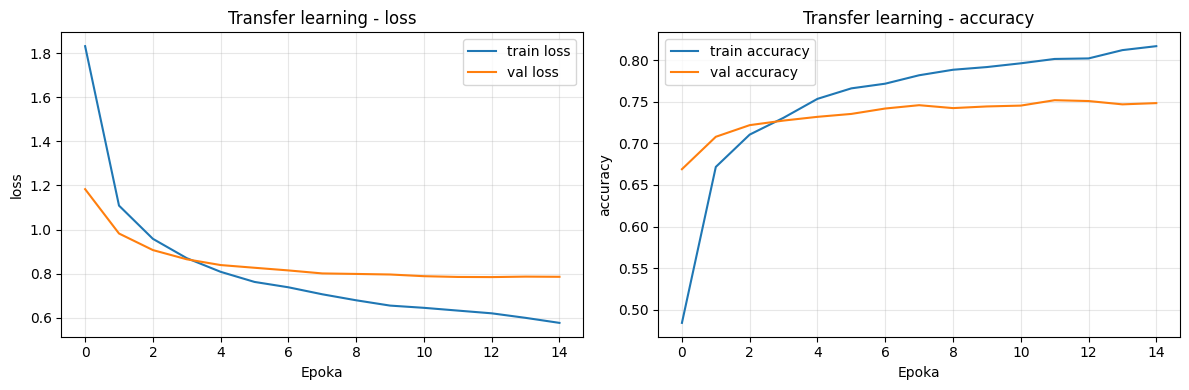

{'accuracy': 0.7595, 'top5': 0.9625}


In [33]:
bazowy = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(64, 64, 3))
bazowy.trainable = False 

model_transfer = Sequential([
    layers.Input((32, 32, 3)),
    layers.Resizing(64, 64),
    layers.Rescaling(255.0),        
    bazowy,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(LICZBA_KLAS, activation='softmax'),
])
historia = trenuj(model_transfer, epochs=15)
wykres_krzywych_uczenia(historia, metryki=('loss', 'accuracy'), tytul='Transfer learning')
wyniki['Transfer'] = oblicz_metryki(model_transfer)
print(wyniki['Transfer'])

## 9. Ocena najlepszego modelu

Najlepszy model: Transfer


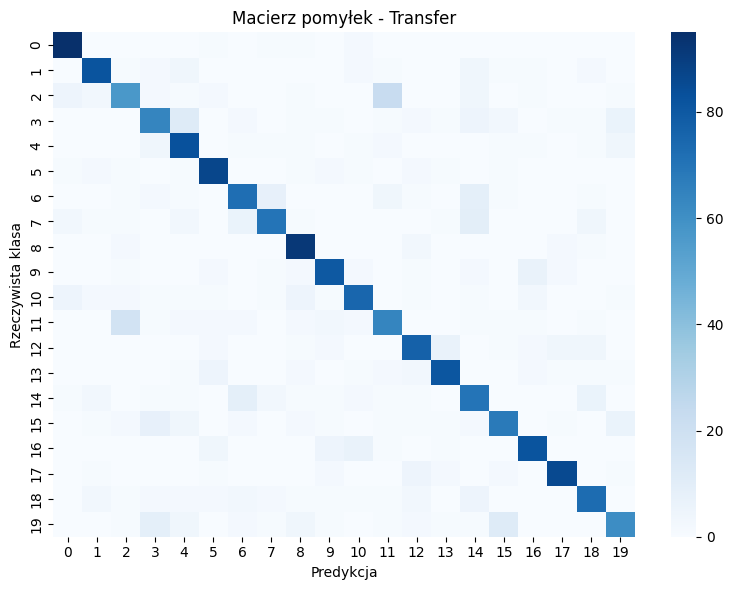

              precision    recall  f1-score   support

           0       0.86      0.95      0.90       100
           1       0.84      0.82      0.83       100
           2       0.65      0.57      0.61       100
           3       0.67      0.64      0.65       100
           4       0.69      0.83      0.75       100
           5       0.80      0.87      0.83       100
           6       0.73      0.72      0.72       100
           7       0.80      0.70      0.74       100
           8       0.78      0.92      0.84       100
           9       0.80      0.80      0.80       100
          10       0.78      0.75      0.77       100
          11       0.63      0.64      0.63       100
          12       0.75      0.77      0.76       100
          13       0.84      0.81      0.83       100
          14       0.61      0.70      0.65       100
          15       0.75      0.68      0.71       100
          16       0.82      0.82      0.82       100
          17       0.89    

In [34]:
modele = {'MLP': model_mlp, 'CNN': model_cnn, 'CNN+reg': model_cnn_reg, 'Transfer': model_transfer}
najlepszy_nazwa = max(wyniki, key=lambda k: wyniki[k]['accuracy'])
najlepszy = modele[najlepszy_nazwa]
print("Najlepszy model:", najlepszy_nazwa)

y_pred = najlepszy.predict(x_test, verbose=0).argmax(axis=1)
macierz_pomylek(y_test, y_pred, tytul=f'Macierz pomyłek - {najlepszy_nazwa}')
print(raport_klasyfikacji(y_test, y_pred))

## 10. Porównanie i wnioski

In [35]:
tabela = tabela_porownawcza(wyniki)
tabela.sort_values('accuracy', ascending=False)

,accuracy,top5
Transfer,0.7595,0.9625
CNN,0.5145,0.8480
CNN+reg,0.4505,0.8280
MLP,0.3120,0.7095


**Wnioski:**
- **CNN znacząco bije MLP** accuracy 0.51 vs 0.31 (+20 pp). Splot wychwytuje lokalne wzorce przestrzenne, których spłaszczony MLP nie widzi.
- **Regularyzacja (augmentacja + BatchNorm + Dropout)** tutaj NIE pomogła accuracy spadło do 0.45 (z 0.51 dla zwykłej CNN). Mocna augmentacja i Dropout 0.5 utrudniają zbieżność, a przy małym zbiorze (8000 obrazów), ograniczonej liczbie epok i EarlyStopping (patience 5) model nie zdążył się douczyć (niedouczenie val_accuracy wciąż rosło przy zatrzymaniu). Regularyzacja opłaciłaby się dopiero przy dłuższym treningu; jej rolą jest lepsza generalizacja, a nie szybki zysk dokładności.
- **Transfer learning najlepszy: accuracy 0.760, top-5 0.962.** Gotowe cechy z ImageNet (EfficientNetB0) przenoszą się świetnie nawet po przeskalowaniu obrazów do 64×64; przy ~500 obrazach na klasę to przewaga nie do pobicia uczeniem sieci od zera.
- **Wyzwania:** mało danych na klasę (500), trening na CPU (transfer najwolniejszy), drobne obiekty 32×32. Dla pełnych 100 klas wynik byłby niższy (mniej przykładów na klasę, trudniejsze rozróżnienie).